# Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
churn_df = pd.read_csv('..//data//raw//churn.csv')
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4250 entries, 0 to 4249
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    4250 non-null   object 
 1   state                          4250 non-null   object 
 2   account_length                 4250 non-null   int64  
 3   area_code                      4250 non-null   object 
 4   international_plan             4250 non-null   bool   
 5   voice_mail_plan                4250 non-null   bool   
 6   number_vmail_messages          4250 non-null   int64  
 7   total_day_minutes              4250 non-null   float64
 8   total_day_calls                4250 non-null   int64  
 9   total_day_charge               4250 non-null   float64
 10  total_eve_minutes              4250 non-null   float64
 11  total_eve_calls                4250 non-null   int64  
 12  total_eve_charge               4250 non-null   f

In [3]:
churn_df.isna().sum()

customer_id                      0
state                            0
account_length                   0
area_code                        0
international_plan               0
voice_mail_plan                  0
number_vmail_messages            0
total_day_minutes                0
total_day_calls                  0
total_day_charge                 0
total_eve_minutes                0
total_eve_calls                  0
total_eve_charge                 0
total_night_minutes              0
total_night_calls                0
total_night_charge               0
total_intl_minutes               0
total_intl_calls                 0
total_intl_charge                0
number_customer_service_calls    0
churn                            0
dtype: int64

In [4]:
churn_df['churn'].value_counts(normalize=True)

churn
False    0.859294
True     0.140706
Name: proportion, dtype: float64

There is class imbalance so we will take this into account while splitting. 

Split training and test set.

In [5]:
churn_train, churn_test = train_test_split(churn_df, test_size=0.2, random_state=67, stratify=churn_df['churn'])

In [6]:
churn_train.head()

,customer_id,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
58,08dd6423-3881-44cd-bc58-dc6acbcd7684,AR,110,area_code_408,False,False,0,55.3,102,9.40,...,124,14.00,200.7,108,9.03,10.2,5,2.75,1,False
3326,dd957965-e185-4930-9f4c-6f9ebba3efaa,WV,141,area_code_415,True,True,37,258.6,84,43.96,...,111,18.87,326.4,97,14.69,11.2,5,3.02,0,False
2486,0f76de9c-c7c1-4dae-a995-3c5b020af486,PA,122,area_code_415,True,False,0,230.9,132,39.25,...,99,20.67,182.4,57,8.21,11.0,2,2.97,0,True
703,76ec4072-cee4-41e7-9ae8-f735bab8814b,ND,190,area_code_415,False,False,0,169.4,102,28.80,...,113,21.55,197.1,93,8.87,8.9,5,2.40,1,False
576,77d791ce-f914-4033-9a8a-e8b72d60b40f,TN,68,area_code_415,False,False,0,178.7,61,30.38,...,84,21.45,255.7,76,11.51,8.4,4,2.27,1,False


In [7]:
churn_targ = churn_train['churn']
churn_feat = churn_train[churn_train.columns.drop(['churn']).to_list()]

In [8]:
num_cols = churn_feat.select_dtypes(include = ['number']).columns.to_list()
cat_cols = churn_feat.select_dtypes(exclude = ['number']).columns.to_list()

In [9]:
churn_train[num_cols].describe()

,account_length,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
count,3400.000000,3400.000000,3400.000000,3400.000000,3400.000000,3400.000000,3400.000000,3400.000000,3400.000000,3400.000000,3400.000000,3400.000000,3400.000000,3400.000000,3400.000000
mean,100.526471,7.722941,179.952206,99.932941,30.592424,200.811676,100.266765,17.069221,200.415382,99.575294,9.018835,10.256353,4.405588,2.769741,1.557941
std,39.749753,13.531859,53.958653,19.915611,9.173007,50.214629,19.924313,4.268294,50.548391,20.027744,2.274695,2.785833,2.437431,0.752138,1.314659
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,0.000000,143.600000,87.000000,24.410000,166.675000,87.000000,14.167500,167.075000,86.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,99.000000,0.000000,180.150000,100.000000,30.625000,201.400000,101.000000,17.120000,201.300000,100.000000,9.060000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,16.250000,215.900000,113.000000,36.700000,234.225000,114.000000,19.912500,234.700000,113.000000,10.560000,12.000000,6.000000,3.240000,2.000000
max,243.000000,52.000000,346.800000,165.000000,58.960000,359.300000,170.000000,30.540000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


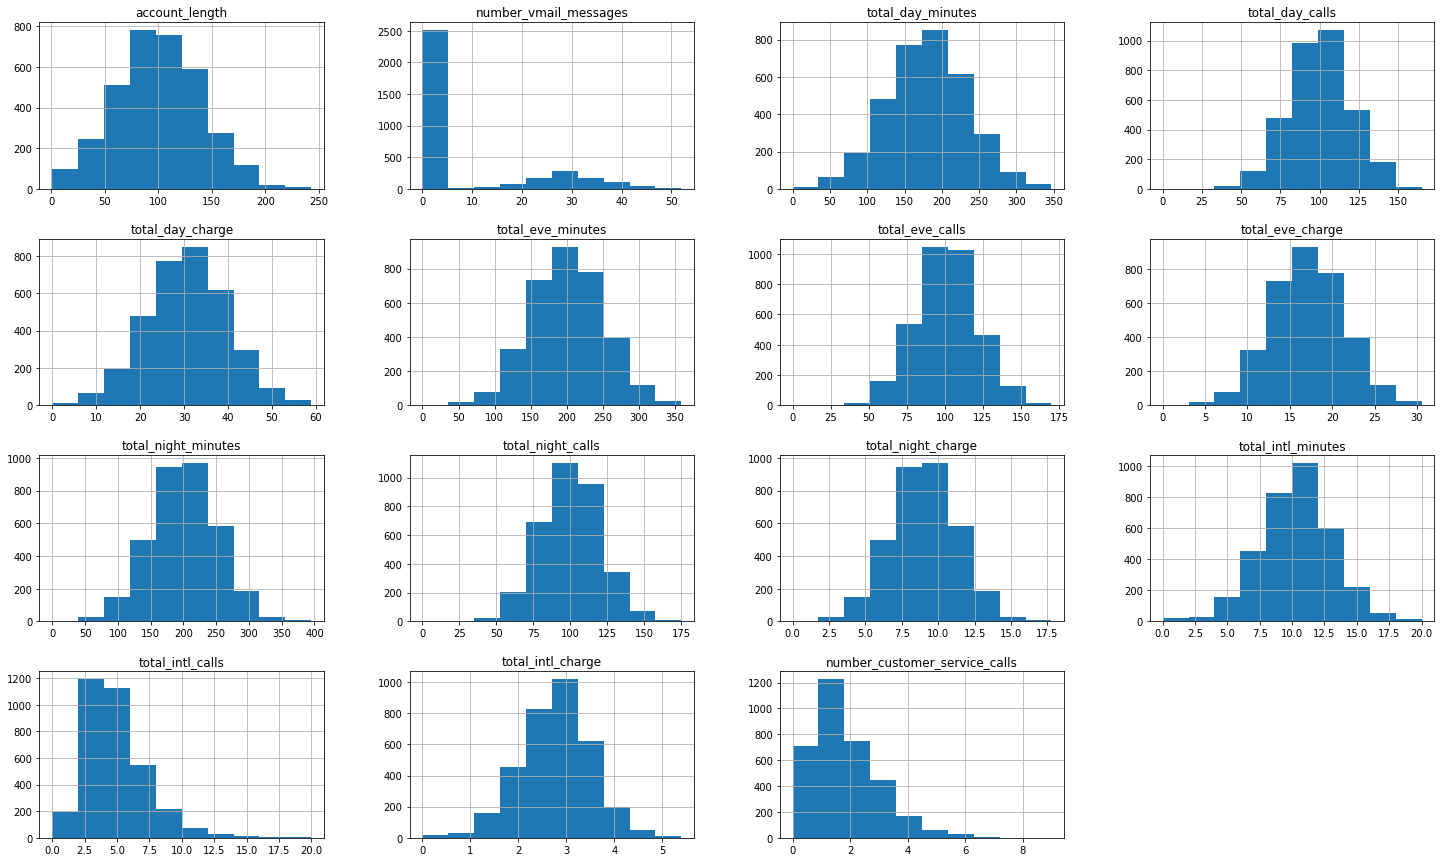

In [10]:
churn_train[num_cols].hist(figsize = (25, 15))
plt.show()

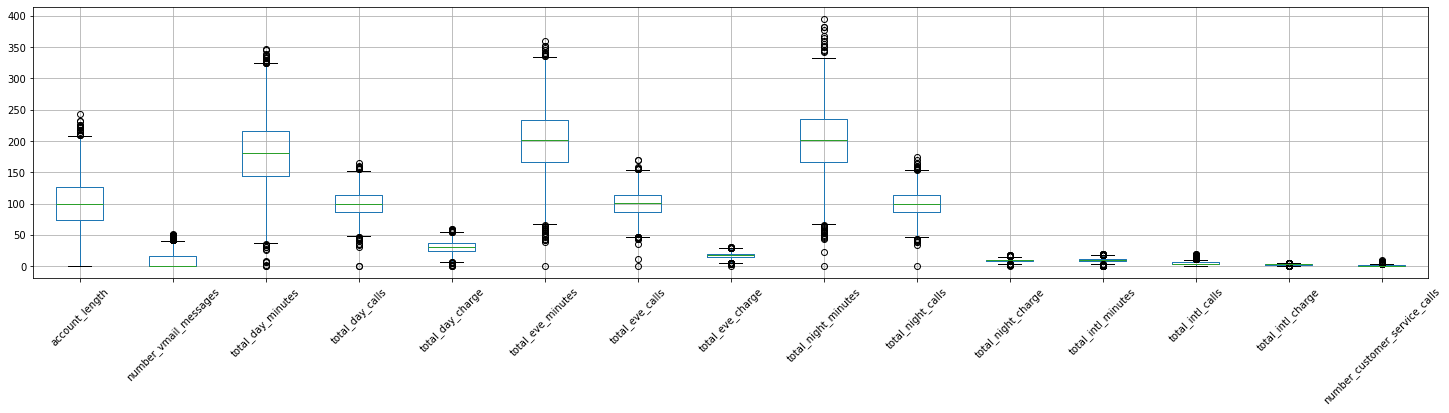

In [11]:
churn_train[num_cols].boxplot(figsize = (25, 5), rot = 45)
plt.show()

In [12]:
churn_train[num_cols].corr()

,account_length,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
account_length,1.000000,0.011083,0.000365,0.009165,0.000362,-0.000775,0.001213,-0.000764,-0.011148,-0.008005,-0.011162,0.003377,0.034006,0.003391,-0.002853
number_vmail_messages,0.011083,1.000000,-0.000099,0.005301,-0.000102,-0.002538,-0.000681,-0.002524,0.018265,0.015158,0.018262,0.007583,-0.000463,0.007547,-0.006854
total_day_minutes,0.000365,-0.000099,1.000000,-0.007466,1.000000,-0.017832,0.015252,-0.017846,0.000921,0.005856,0.000913,-0.021769,0.014598,-0.021718,0.000812
total_day_calls,0.009165,0.005301,-0.007466,1.000000,-0.007461,0.009700,-0.002431,0.009690,-0.003260,0.000679,-0.003255,0.019455,0.014349,0.019553,-0.015370
total_day_charge,0.000362,-0.000102,1.000000,-0.007461,1.000000,-0.017833,0.015252,-0.017847,0.000924,0.005853,0.000916,-0.021775,0.014595,-0.021724,0.000803
total_eve_minutes,-0.000775,-0.002538,-0.017832,0.009700,-0.017833,1.000000,-0.002192,1.000000,-0.015644,0.021487,-0.015679,-0.008045,0.019948,-0.008016,-0.009528
total_eve_calls,0.001213,-0.000681,0.015252,-0.002431,0.015252,-0.002192,1.000000,-0.002172,0.012528,-0.008866,0.012542,-0.013279,0.001655,-0.013335,0.014578
total_eve_charge,-0.000764,-0.002524,-0.017846,0.009690,-0.017847,1.000000,-0.002172,1.000000,-0.015655,0.021476,-0.015690,-0.008049,0.019943,-0.008019,-0.009535
total_night_minutes,-0.011148,0.018265,0.000921,-0.003260,0.000924,-0.015644,0.012528,-0.015655,1.000000,0.016821,0.999999,-0.006694,-0.019674,-0.006627,-0.005699
total_night_calls,-0.008005,0.015158,0.005856,0.000679,0.005853,0.021487,-0.008866,0.021476,0.016821,1.000000,0.016815,0.006150,0.020585,0.006113,-0.001110


Charges do not add usable info.

In [13]:
drop_cols =  ['customer_id', 'total_day_charge', 'total_eve_charge', 'total_night_charge', 'total_intl_charge']
churn_train = churn_train.drop(columns = drop_cols)
churn_test = churn_test.drop(columns = drop_cols)
churn_train.to_csv('..//data//processed//churn_known.csv', index = False)
churn_test.to_csv('..//data//processed//churn_holdout.csv', index = False)